<div align="center">

# Features Evaluation
</div>

In [1]:
import h5py
import numpy as np
import pandas as pd



In [32]:

# -----------------------------
# 1. LOAD DATA
# -----------------------------
file_path = "../Features/chb01_03_features.mat"

with h5py.File(file_path, 'r') as f:
    X = f['all_feats'][:]          # (windows, 1530)
    y = f['all_labels'][:].squeeze()

print("X shape:", X.shape)
print("y distribution:", np.bincount(y.astype(int)))


X shape: (1437, 1530)
y distribution: [1421   16]


X shape: (1437, 1530)
NaNs: 0
Infs: 0
Label distribution: [1421   16]

--- SUMMARY ---
Bad windows: 0 / 1437

--- WORST WINDOWS ---
win  1417 | max_abs=7.435e-01 | min=3.011e-05 | nan_inf=0
win  1209 | max_abs=7.026e-01 | min=3.361e-05 | nan_inf=0
win  1349 | max_abs=6.862e-01 | min=2.408e-05 | nan_inf=0
win  1418 | max_abs=6.821e-01 | min=2.055e-05 | nan_inf=0
win  1350 | max_abs=6.722e-01 | min=5.230e-06 | nan_inf=0
win   394 | max_abs=6.482e-01 | min=3.854e-05 | nan_inf=0
win  1420 | max_abs=6.451e-01 | min=7.088e-05 | nan_inf=0
win  1258 | max_abs=6.316e-01 | min=2.866e-05 | nan_inf=0
win   624 | max_abs=6.221e-01 | min=3.137e-05 | nan_inf=0
win  1348 | max_abs=6.160e-01 | min=4.392e-05 | nan_inf=0

--- BY LABEL ---
label 0: mean max_abs = 2.699e-01, bad rate = 0.000
label 1: mean max_abs = 3.982e-01, bad rate = 0.000


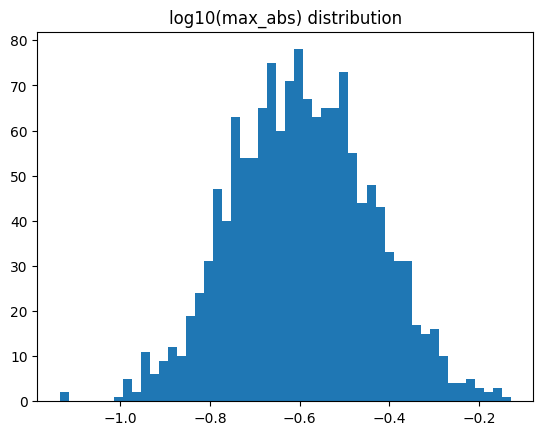

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# BASIC CHECKS
# -----------------------------
print("X shape:", X.shape)
print("NaNs:", np.isnan(X).sum())
print("Infs:", np.isinf(X).sum())

y = y.astype(int)
print("Label distribution:", np.bincount(y))

# -----------------------------
# PER-WINDOW DIAGNOSTICS
# -----------------------------
n_nonfinite = (~np.isfinite(X)).sum(axis=1)
max_abs = np.nanmax(np.abs(X), axis=1)
min_val = np.nanmin(X, axis=1)
mean_abs = np.nanmean(np.abs(X), axis=1)

# -----------------------------
# GLOBAL THRESHOLD (data-driven)
# -----------------------------

CEIL = 50.0

bad = (
    (n_nonfinite > 0) |
    (max_abs > CEIL) |
    (min_val < -1e-3)
)

bad_idx = np.where(bad)[0]

print("\n--- SUMMARY ---")
print(f"Bad windows: {len(bad_idx)} / {len(X)}")

# -----------------------------
# TOP WORST WINDOWS
# -----------------------------
worst = np.argsort(max_abs)[::-1][:10]

print("\n--- WORST WINDOWS ---")
for i in worst:
    print(
        f"win {i:5d} | "
        f"max_abs={max_abs[i]:.3e} | "
        f"min={min_val[i]:.3e} | "
        f"nan_inf={n_nonfinite[i]}"
    )

# -----------------------------
# LABEL COMPARISON (VERY IMPORTANT)
# -----------------------------
print("\n--- BY LABEL ---")
for label in [0, 1]:
    idx = np.where(y == label)[0]
    print(
        f"label {label}: "
        f"mean max_abs = {np.mean(max_abs[idx]):.3e}, "
        f"bad rate = {np.mean(bad[idx]):.3f}"
    )

# -----------------------------
# DISTRIBUTION CHECK
# -----------------------------
plt.hist(np.log10(max_abs + 1e-12), bins=50)
plt.title("log10(max_abs) distribution")
plt.show()